# 02 — Preprocessing

**Input:** `data/raw/M1_data.csv` (includes m1_purchase target field)  
**Output:** `data/processed/processed_m1_data.csv` (21 features scaled + target)

Steps:
1. Load M1 dataset
2. Separate target variable (`m1_purchase`) from features
3. Impute missing values
4. Outlier detection & removal (IQR method)
5. Encode categoricals
6. Feature scaling (StandardScaler) — applied ONLY to features, not target


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PLOT_DIR = Path('../plots/preprocessing')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv('../data/raw/M1_data.csv')
print('Raw shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Raw shape: (133, 22)
Columns: ['trust_apple', 'interest_computers', 'age_computer', 'user_pcmac', 'appleproducts_count', 'familiarity_m1', 'f_batterylife', 'f_price', 'f_size', 'f_multitasking', 'f_noise', 'f_performance', 'f_neural', 'f_synergy', 'f_performanceloss', 'm1_consideration', 'm1_purchase', 'gender', 'age_group', 'income_group', 'status', 'domain']


,trust_apple,interest_computers,age_computer,user_pcmac,appleproducts_count,familiarity_m1,f_batterylife,f_price,f_size,f_multitasking,...,f_neural,f_synergy,f_performanceloss,m1_consideration,m1_purchase,gender,age_group,income_group,status,domain
0,No,4,20,PC,0,No,5,4,3,4,...,2,1,1,1,Yes,Male,2,2,Student,Science
1,Yes,2,4,PC,1,No,5,5,5,3,...,2,2,4,2,No,Male,2,3,Employed,Finance
2,Yes,5,6,PC,0,No,3,4,2,4,...,2,2,2,4,Yes,Male,2,2,Student,IT & Technology
3,Yes,2,6,Apple,4,No,4,3,3,4,...,4,4,3,2,No,Female,2,2,Student,Arts & Culture
4,Yes,4,4,Apple,7,Yes,5,3,3,4,...,3,4,4,4,Yes,Male,5,7,Employed,Hospitality


## Step 1:  Drop Unused Columns

In [2]:
# No ID column in M1 dataset, but drop if exists
df = df.drop(columns=['ID'], errors='ignore')
print('After drop unused columns:', df.shape)

After drop unused columns: (133, 22)


## Step 1b: Separate Target Variable

In [3]:
# Separate target variable (m1_purchase) from features
# m1_purchase should NOT be scaled — it's a classification target
if 'm1_purchase' in df.columns:
    y = df['m1_purchase'].copy()  # Save target variable
    df_features = df.drop(columns=['m1_purchase'])
    print(f"Target (m1_purchase) separated.")
    print(f"  Distribution: {y.value_counts().to_dict()}")
else:
    print("Warning: m1_purchase column not found. Proceeding without target variable.")

Target (m1_purchase) separated.
  Distribution: {'Yes': 88, 'No': 45}


## Step 2: Handle Missing Values

In [4]:
print('Missing before imputation:')
print(df_features.isnull().sum()[df_features.isnull().sum() > 0])

# Numeric: fill with median
num_cols = df_features.select_dtypes(include='number').columns.tolist()
for col in num_cols:
    df_features[col].fillna(df_features[col].median(), inplace=True)

# Categorical: fill with mode
cat_cols = df_features.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_features[col].fillna(df_features[col].mode()[0], inplace=True)

print('\nMissing after imputation:', df_features.isnull().sum().sum())

Missing before imputation:
Series([], dtype: int64)

Missing after imputation: 0


## Step 3 : Outlier Detection & Removal (IQR)

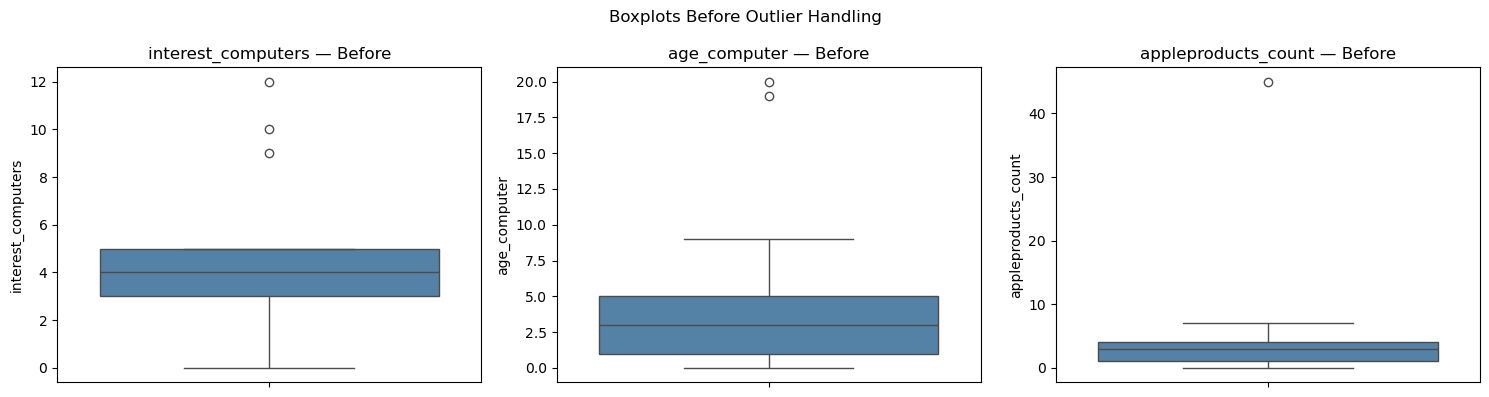

In [5]:
# --- Boxplots BEFORE handling ---
numeric_cols = df_features.select_dtypes(include='number').columns.tolist()
if len(numeric_cols) >= 3:
    sample_cols = numeric_cols[:3]
else:
    sample_cols = numeric_cols

fig, axes = plt.subplots(1, len(sample_cols), figsize=(15, 4))
if len(sample_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, sample_cols):
    sns.boxplot(y=df_features[col], ax=ax, color='steelblue')
    ax.set_title(f'{col} — Before')
plt.suptitle('Boxplots Before Outlier Handling')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'boxplots_before_outlier_handling.png', dpi=150)
plt.show()

In [6]:
# IQR Capping (Winsorization) — cap outliers at 1.5*IQR fences
outlier_cols = df_features.select_dtypes(include='number').columns.tolist()

for col in outlier_cols:
    Q1  = df_features[col].quantile(0.25)
    Q3  = df_features[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_features[col] < lower) | (df_features[col] > upper)).sum()
    # Cap (winsorise) instead of drop — preserves row count
    df_features[col] = df_features[col].clip(lower=lower, upper=upper)
    if outliers > 0:
        print(f'{col}: {outliers} outliers capped  (lower={lower:.1f}, upper={upper:.1f})')

interest_computers: 3 outliers capped  (lower=0.0, upper=8.0)
age_computer: 2 outliers capped  (lower=-5.0, upper=11.0)
appleproducts_count: 1 outliers capped  (lower=-3.5, upper=8.5)
f_batterylife: 2 outliers capped  (lower=2.5, upper=6.5)
f_multitasking: 3 outliers capped  (lower=2.5, upper=6.5)
f_performance: 3 outliers capped  (lower=2.5, upper=6.5)
f_synergy: 13 outliers capped  (lower=1.5, upper=5.5)
f_performanceloss: 8 outliers capped  (lower=1.5, upper=5.5)
age_group: 19 outliers capped  (lower=0.5, upper=4.5)


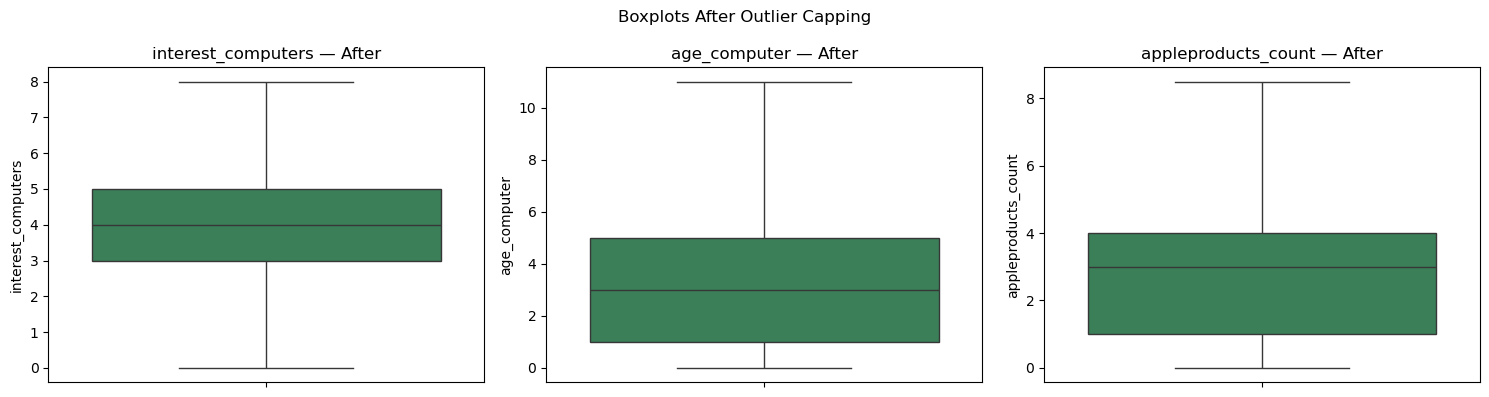

In [7]:
# --- Boxplots AFTER handling ---
numeric_cols = df_features.select_dtypes(include='number').columns.tolist()
if len(numeric_cols) >= 3:
    sample_cols = numeric_cols[:3]
else:
    sample_cols = numeric_cols

fig, axes = plt.subplots(1, len(sample_cols), figsize=(15, 4))
if len(sample_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, sample_cols):
    sns.boxplot(y=df_features[col], ax=ax, color='seagreen')
    ax.set_title(f'{col} — After')
plt.suptitle('Boxplots After Outlier Capping')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'boxplots_after_outlier_capping.png', dpi=150)
plt.show()

## Step 4 : Encode Categoricals

In [8]:
le = LabelEncoder()

# M1 Dataset categorical columns to encode
cat_cols = df_features.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

# Binary encoding for Yes/No columns only (not user_pcmac — that is device type)
binary_map = {'Yes': 1, 'No': 0}
yes_no_cols = ['trust_apple', 'familiarity_m1']
for col in yes_no_cols:
    if col in df_features.columns:
        df_features[col] = df_features[col].map(binary_map)
        print(f'Encoded {col} with binary map')

# user_pcmac: Apple vs PC/Others (also accepts Yes/No from forms: Mac/PC)
if 'user_pcmac' in df_features.columns:
    pcmac_norm = df_features['user_pcmac'].astype(str).str.strip().str.capitalize()
    pcmac_map = {'Apple': 1, 'Pc': 0, 'Hp': 0, 'Other': 0, 'Yes': 1, 'No': 0}
    df_features['user_pcmac'] = pcmac_norm.map(pcmac_map)
    if df_features['user_pcmac'].isnull().any():
        bad = sorted(pcmac_norm[df_features['user_pcmac'].isnull()].unique().tolist())
        raise ValueError(f'Unknown user_pcmac values after normalize: {bad}')
    print('Encoded user_pcmac (Apple/Yes=1, PC or other/No=0)')

# Label encode remaining categorical columns (gender, status, domain, etc.)
for col in df_features.select_dtypes(include='object').columns:
    if col not in yes_no_cols:
        df_features[col] = le.fit_transform(df_features[col].astype(str))
        print(f'Label encoded {col}')

print('\nDtypes after encoding:')
print(df_features.dtypes)
df_features.head()

Categorical columns to encode: ['trust_apple', 'user_pcmac', 'familiarity_m1', 'gender', 'status', 'domain']
Encoded trust_apple with binary map
Encoded familiarity_m1 with binary map
Encoded user_pcmac (Apple/Yes=1, PC or other/No=0)
Label encoded gender
Label encoded status
Label encoded domain

Dtypes after encoding:
trust_apple              int64
interest_computers       int64
age_computer             int64
user_pcmac               int64
appleproducts_count    float64
familiarity_m1           int64
f_batterylife          float64
f_price                  int64
f_size                   int64
f_multitasking         float64
f_noise                  int64
f_performance          float64
f_neural                 int64
f_synergy              float64
f_performanceloss      float64
m1_consideration         int64
gender                   int64
age_group              float64
income_group             int64
status                   int64
domain                   int64
dtype: object


,trust_apple,interest_computers,age_computer,user_pcmac,appleproducts_count,familiarity_m1,f_batterylife,f_price,f_size,f_multitasking,...,f_performance,f_neural,f_synergy,f_performanceloss,m1_consideration,gender,age_group,income_group,status,domain
0,0,4,11,0,0.0,0,5.0,4,3,4.0,...,2.5,2,1.5,1.5,1,1,2.0,2,3,20
1,1,2,4,0,1.0,0,5.0,5,5,3.0,...,5.0,2,2.0,4.0,2,1,2.0,3,0,9
2,1,5,6,0,0.0,0,3.0,4,2,4.0,...,4.0,2,2.0,2.0,4,1,2.0,2,3,12
3,1,2,6,1,4.0,0,4.0,3,3,4.0,...,4.0,4,4.0,3.0,2,0,2.0,2,3,2
4,1,4,4,1,7.0,1,5.0,3,3,4.0,...,5.0,3,4.0,4.0,4,1,4.5,7,0,11


In [9]:
# Diagnostic: inspect raw df and df_features values after encoding
print('Raw df sample (first 5 rows):')
print(df.head())
print('\nProcessed feature DF (first 5 rows):')
print(df_features.head())

print('\nEncoded categorical columns sample values:')
for col in ['trust_apple', 'user_pcmac', 'familiarity_m1', 'gender', 'status', 'domain']:
    if col in df_features.columns:
        print(f"  {col}: {pd.Series(df_features[col]).unique()[:10]}")

Raw df sample (first 5 rows):
  trust_apple  interest_computers  age_computer user_pcmac  \
0          No                   4            20         PC   
1         Yes                   2             4         PC   
2         Yes                   5             6         PC   
3         Yes                   2             6      Apple   
4         Yes                   4             4      Apple   

   appleproducts_count familiarity_m1  f_batterylife  f_price  f_size  \
0                    0             No              5        4       3   
1                    1             No              5        5       5   
2                    0             No              3        4       2   
3                    4             No              4        3       3   
4                    7            Yes              5        3       3   

   f_multitasking  ...  f_neural  f_synergy  f_performanceloss  \
0               4  ...         2          1                  1   
1               3  ...    

## Step 5 : Feature Scaling (StandardScaler)

In [10]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=df_features.columns)

# Add the target variable back (unscaled) for classification training
if 'm1_purchase' in locals():
    df_scaled['m1_purchase'] = y.reset_index(drop=True).values
    print("✓ Target variable (m1_purchase) added to scaled data")

print('\nScaled stats (mean ≈ 0, std ≈ 1):')
print(df_scaled.describe().round(2))
print(f'\nShape: {df_scaled.shape}')


Scaled stats (mean ≈ 0, std ≈ 1):
       trust_apple  interest_computers  age_computer  user_pcmac  \
count       133.00              133.00        133.00      133.00   
mean          0.00                0.00          0.00        0.00   
std           1.00                1.00          1.00        1.00   
min          -2.45               -3.27         -1.12       -1.35   
25%           0.41               -0.73         -0.74       -1.35   
50%           0.41                0.11          0.03        0.74   
75%           0.41                0.96          0.81        0.74   
max           0.41                3.50          3.12        0.74   

       appleproducts_count  familiarity_m1  f_batterylife  f_price  f_size  \
count               133.00          133.00         133.00   133.00  133.00   
mean                 -0.00            0.00          -0.00    -0.00   -0.00   
std                   1.00            1.00           1.00     1.00    1.00   
min                  -1.37           -0.

## Correlation Heatmap (after processing)

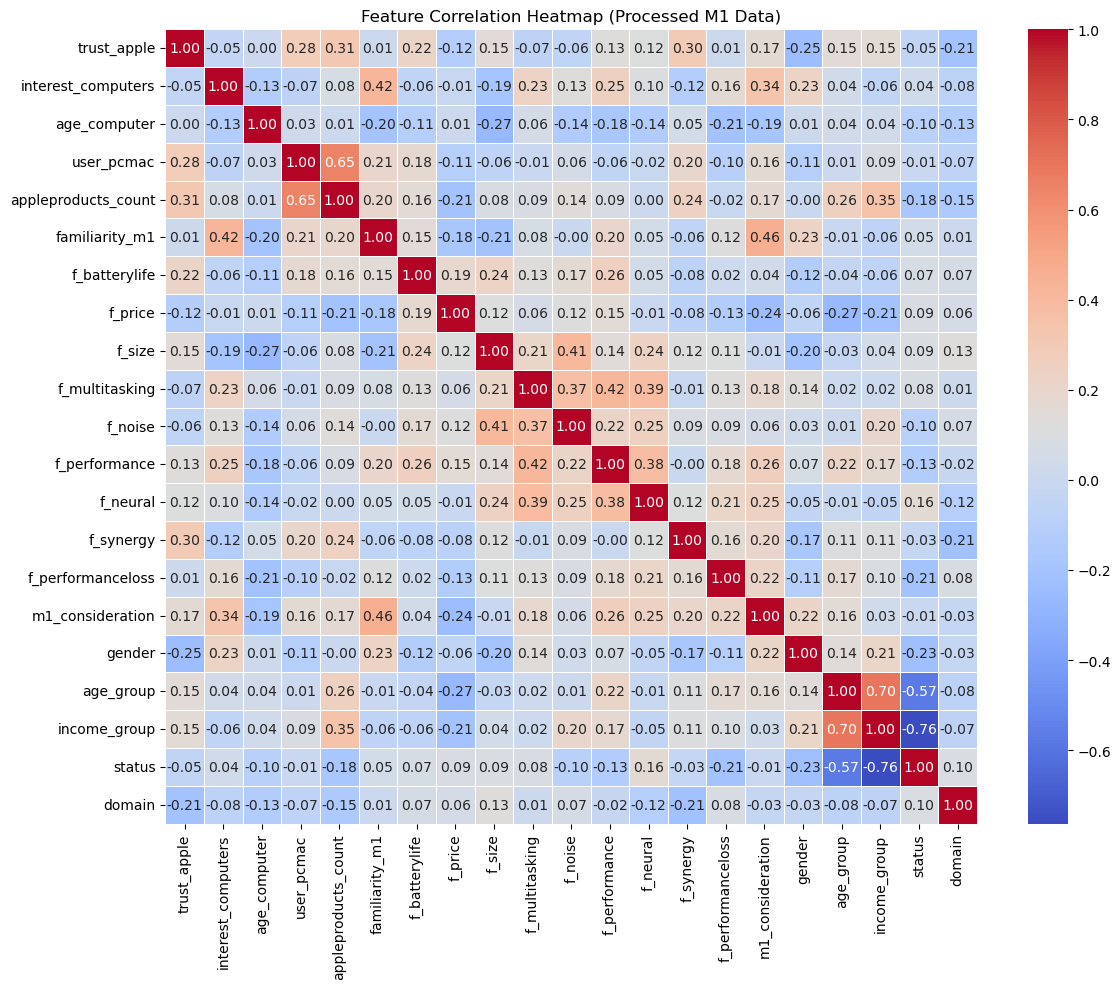

In [11]:
plt.figure(figsize=(12, 10))
# Correlation of features only (exclude target if present)
df_for_corr = df_scaled.drop(columns=['m1_purchase'], errors='ignore')
sns.heatmap(df_for_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap (Processed M1 Data)')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'correlation_heatmap_processed_m1_data.png', dpi=150)
plt.show()

## Save Processed Data

In [12]:
# Save processed data with target variable
df_scaled['m1_purchase'] = y.map({'Yes': 1, 'No': 0}).values
output_path = '../data/processed/processed_m1_data.csv'
df_scaled.to_csv(output_path, index=False)
print(f'✓ Saved processed_m1_data.csv — shape: {df_scaled.shape}')
print(f'  Columns ({len(df_scaled.columns)}): {list(df_scaled.columns)}')
print(f'  m1_purchase distribution: {df_scaled["m1_purchase"].value_counts().to_dict()}')

# Save preprocessing artifacts for API inference
import pickle
import os

models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Save scaler
with open(os.path.join(models_dir, 'scaler_m1.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print(f'✓ Saved scaler_m1.pkl')

# Save preprocessing config for M1 dataset
preprocess_config = {
    'binary_map': {'Yes': 1, 'No': 0},
    'user_pcmac_map': {'Apple': 1, 'Pc': 0, 'Hp': 0, 'Other': 0, 'Yes': 1, 'No': 0},
    'label_encoders': {},  # Store encoders for categorical columns if needed
}

with open(os.path.join(models_dir, 'encoders_m1.pkl'), 'wb') as f:
    pickle.dump(preprocess_config, f)
print(f'✓ Saved encoders_m1.pkl with preprocessing config')

✓ Saved processed_m1_data.csv — shape: (133, 22)
  Columns (22): ['trust_apple', 'interest_computers', 'age_computer', 'user_pcmac', 'appleproducts_count', 'familiarity_m1', 'f_batterylife', 'f_price', 'f_size', 'f_multitasking', 'f_noise', 'f_performance', 'f_neural', 'f_synergy', 'f_performanceloss', 'm1_consideration', 'gender', 'age_group', 'income_group', 'status', 'domain', 'm1_purchase']
  m1_purchase distribution: {1: 88, 0: 45}
✓ Saved scaler_m1.pkl
✓ Saved encoders_m1.pkl with preprocessing config
